In [1]:
import datasets
import keras_hub
import transformers
import numpy as np
import tensorflow as tf
import tqdm.notebook as tqdm
import sklearn.model_selection
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import keras
from collections.abc import Callable

2025-09-29 14:44:32.361875: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-29 14:44:32.368916: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759121072.377786  549642 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759121072.380790  549642 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759121072.387502  549642 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass

In [3]:
train = datasets.load_dataset('wangrongsheng/ag_news', split='train')
test  = datasets.load_dataset('wangrongsheng/ag_news', split='test')

In [4]:
tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2')

In [5]:
tokenizer.pad_token = tokenizer.eos_token

In [6]:
def get_name(pref: str | None, suf: str, sep: str = '_') -> str | None:
    return pref and pref + sep + suf

In [7]:
def get_lstm_layer(ndim: int, name: None | str = None) -> Callable[[keras.KerasTensor, tuple[keras.KerasTensor, keras.KerasTensor]], tuple[keras.KerasTensor, tuple[keras.KerasTensor, keras.KerasTensor]]]:
    forget_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'forget_gate'))
    input_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'input_gate'))
    tanh = keras.layers.Dense(ndim, activation='tanh', name=get_name(name, 'tanh'))
    output_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'output_gate'))
    mul_1 = keras.layers.Multiply(name=get_name(name, 'mul_1'))
    mul_2 = keras.layers.Multiply(name=get_name(name, 'mul_2'))
    mul_3 = keras.layers.Multiply(name=get_name(name, 'mul_3'))

    add = keras.layers.Add(name=get_name(name, 'add'))
    concat = keras.layers.Concatenate(name=get_name(name, 'concat'))
    def lstm(x: keras.KerasTensor, state: tuple[keras.KerasTensor, keras.KerasTensor]) -> tuple[keras.KerasTensor, tuple[keras.KerasTensor, keras.KerasTensor]]:
        l, s = state
        xs = concat([x, s])
        l = mul_1([l, forget_gate(xs)])
        l = add([l, mul_2([input_gate(xs), tanh(xs)])])
        s = mul_3([output_gate(xs), keras.activations.tanh(l)])
        return s, (l, s)

    return lstm

In [8]:
lstm = get_lstm_layer(128, 'first')
lstm

<function __main__.get_lstm_layer.<locals>.lstm(x: keras.src.backend.common.keras_tensor.KerasTensor, state: tuple[keras.src.backend.common.keras_tensor.KerasTensor, keras.src.backend.common.keras_tensor.KerasTensor]) -> tuple[keras.src.backend.common.keras_tensor.KerasTensor, tuple[keras.src.backend.common.keras_tensor.KerasTensor, keras.src.backend.common.keras_tensor.KerasTensor]]>

In [9]:
x_input = keras.layers.Input((128,), name='x')
l_input = keras.layers.Input((128,), name='l')
s_input = keras.layers.Input((128,), name='s')

In [10]:
x = lstm(x_input, (l_input, s_input))

I0000 00:00:1759121152.169743  549642 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19876 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


In [11]:
model = keras.Model(inputs=[x_input, [l_input, s_input]], outputs=x)

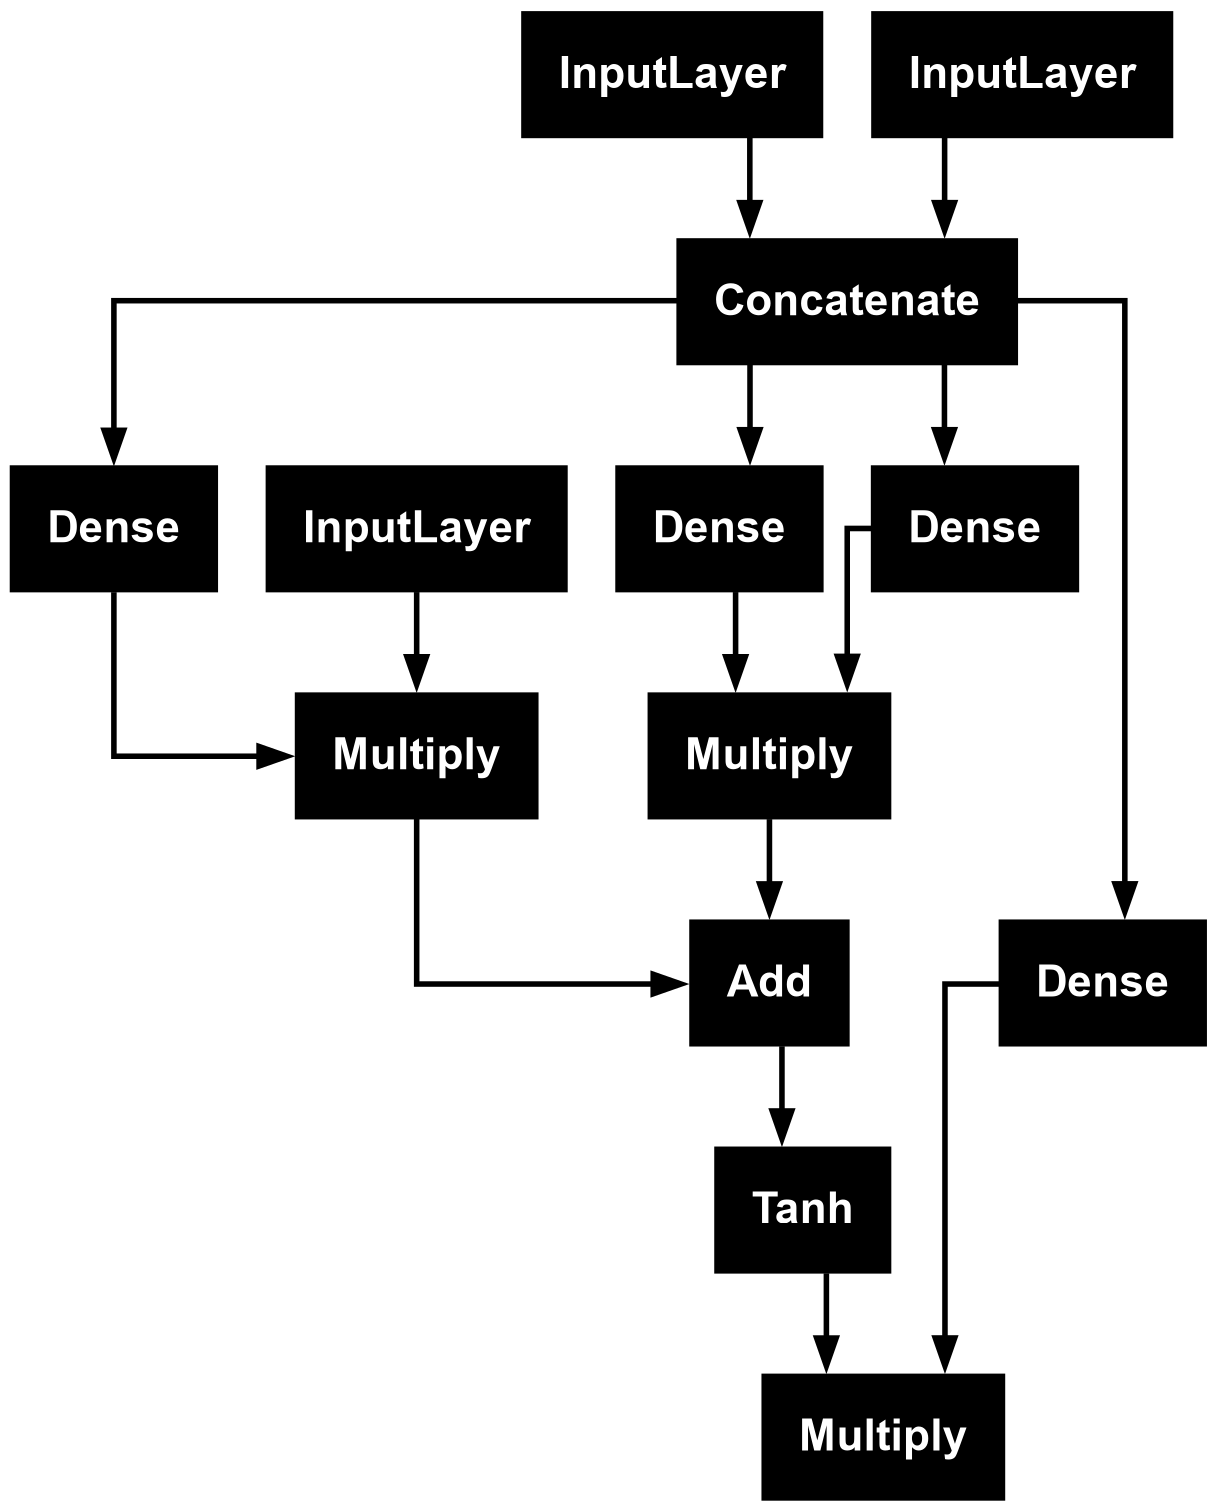

In [12]:
keras.utils.plot_model(model)

In [13]:
def get_gen_state_lstm(ndim: int):
    def gen_state_lstm(batch_size: int, dtype: tf.DType):
        return tf.zeros([batch_size, ndim], dtype=dtype), tf.zeros([batch_size, ndim], dtype=dtype)

    return gen_state_lstm

In [112]:
def apply_rnn(x: tf.Tensor, model: keras.Model, gen_state):
    batch_size = tf.shape(x)[0]
    state = gen_state(batch_size, x.dtype)
    n = tf.shape(x)[1]
    return tf.while_loop(
        (lambda i, _: tf.less(i, n)), 
        (lambda i, state: (i + 1, model([x[:, i], state])[1])),
        [tf.constant(0), state]
    )[1]

In [113]:
@tf.function
def apply_rnn(x: tf.Tensor, model: keras.Model, gen_state):
    batch_size = tf.shape(x)[0]
    state = gen_state(batch_size, x.dtype)
    n = tf.shape(x)[1]
    i = tf.constant(0)
    while i < n:
        _, state = model([x[:, i], state])
        i = i + 1
    return state

In [114]:
@tf.function
def apply_rnn_fun(x: tf.Tensor, model: keras.Model, gen_state):
    batch_size = tf.shape(x)[0]
    state = gen_state(batch_size, x.dtype)
    n = tf.shape(x)[1]
    i = tf.constant(0)
    while i < n:
        _, state = model(x[:, i], state)
        i = i + 1
    return state

In [16]:
apply_rnn(tf.random.uniform(shape=(2, 16, 128)), model, get_gen_state_lstm(128))

(<tf.Tensor: shape=(), dtype=int32, numpy=16>,
 (<tf.Tensor: shape=(2, 128), dtype=float32, numpy=
  array([[-0.01196229,  0.484088  , -0.04408052,  0.41061246,  0.18768507,
          -0.01991504,  0.05629457,  0.7452681 ,  0.33077925, -0.3339679 ,
           0.1738427 , -0.18763697,  0.07275339,  0.10381003, -0.2127291 ,
          -0.0422828 , -0.28881365,  0.05058908,  0.50722873,  0.24298215,
           0.00796779, -0.572833  , -0.13173749,  0.26074368, -0.36723334,
          -0.17450736, -0.09190997,  0.73827857,  0.13044773,  0.44185835,
           0.7227296 , -0.6272501 ,  0.6309309 , -0.6830794 ,  0.2239768 ,
           0.00272268,  0.31447953,  0.17997134,  0.2903046 , -0.33308142,
           0.7553222 , -0.02358805, -0.03337232,  0.5406021 ,  0.08358969,
          -0.49188578,  0.03746345,  0.01594442,  0.6583058 ,  0.15182538,
          -0.4500708 ,  0.34413764, -0.00854373,  0.2090807 , -0.20339677,
           0.88847065,  0.54927945,  0.55011106,  0.62670076, -0.5598323 ,
 

In [17]:
sizes = []
for text in train['text']:
    sizes.append(len(tokenizer(text)['input_ids']))

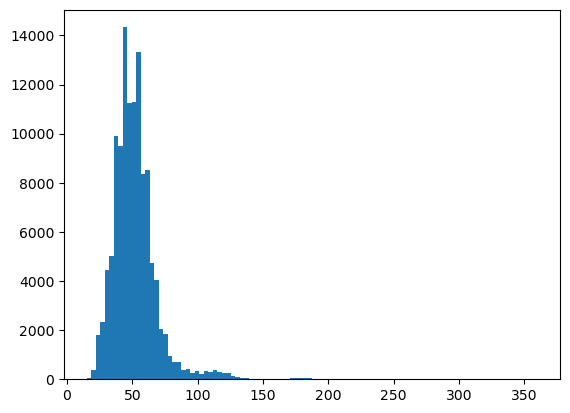

In [19]:
_ = plt.hist(sizes, bins=100)

In [22]:
np.median(sizes)

50.0

In [29]:
max_size = int(np.quantile(sizes, 0.99))
max_size

121

In [30]:
tokens_train = []
for text in train['text']:
    tokens_train.append(tokenizer(text, max_length=max_size, padding="max_length", truncation=True)['input_ids'])

In [31]:
tokens_test = []
for text in test['text']:
    tokens_test.append(tokenizer(text, max_length=max_size, padding="max_length", truncation=True)['input_ids'])

In [33]:
tokens_train = np.array(tokens_train)
tokens_test = np.array(tokens_test)

In [38]:
train_y = np.array(train["label"])
test_y = np.array(test["label"])

In [34]:
tokens_train.shape

(120000, 121)

In [41]:
len(tokenizer.get_vocab())

50257

In [42]:
tokenizer.get_vocab()

{'Ġdwarf': 24603,
 'eled': 18449,
 'Ġinfinitely': 32264,
 'ĠHearth': 31069,
 'ift': 2135,
 'ographies': 41480,
 'ĠSed': 22710,
 'Ġfailed': 4054,
 'bell': 7923,
 'ĠBayer': 48009,
 'recy': 20568,
 'ĠElement': 11703,
 'Ġ314': 34085,
 'ĠSaga': 19743,
 'Ġinconven': 20488,
 'ullivan': 16040,
 'ĠExamination': 50105,
 'Ġcrabs': 49172,
 '389': 29769,
 'Ġdefer': 29135,
 'Ġseminar': 37634,
 'Ġsplend': 32394,
 'Ġbinge': 34735,
 'chlor': 36813,
 'DEF': 32988,
 'Ġenthusiasm': 17131,
 'aha': 12236,
 'itability': 34147,
 'Ġlimiting': 15637,
 'Ġensuing': 29543,
 'Ġrise': 4485,
 'ĠjQuery': 37420,
 'ĠHAR': 43638,
 'Ġshattering': 48883,
 'Ġcorpses': 26750,
 'Ġcrocod': 37565,
 'ĠConn': 20776,
 '-+-+-+-+': 42744,
 '324': 33916,
 'aundering': 23496,
 'Ġhal': 10284,
 'Ġhomegrown': 49847,
 'Ġanalyses': 13523,
 'Ġil': 4229,
 'Ġultras': 32866,
 'gra': 46784,
 'folios': 45242,
 'olf': 4024,
 'jamin': 13337,
 'ambling': 15366,
 'Sleep': 40555,
 'rap': 2416,
 'soever': 15485,
 'rial': 4454,
 'Synopsis': 49771,
 'In

In [8]:
lstm = get_lstm_layer(128, 'first')
lstm

<function __main__.get_lstm_layer.<locals>.lstm(x: keras.src.backend.common.keras_tensor.KerasTensor, state: tuple[keras.src.backend.common.keras_tensor.KerasTensor, keras.src.backend.common.keras_tensor.KerasTensor]) -> tuple[keras.src.backend.common.keras_tensor.KerasTensor, tuple[keras.src.backend.common.keras_tensor.KerasTensor, keras.src.backend.common.keras_tensor.KerasTensor]]>

In [44]:
x_input = keras.layers.Input((128,), name='x')
l_input = keras.layers.Input((128,), name='l')
s_input = keras.layers.Input((128,), name='s')

x = lstm(x_input, (l_input, s_input))

model_lstm = keras.Model(inputs=[x_input, [l_input, s_input]], outputs=x)

In [59]:
embedding = keras.layers.Embedding(len(tokenizer.get_vocab()), 128, name="embedding")
predictions = keras.layers.Dense(4, name="dense_pred")
get_state = get_gen_state_lstm(128)

In [60]:
x = embedding(tokens_train[:2])
x = apply_rnn(x, model_lstm, get_gen_state_lstm(128))[1]
x = predictions(x)

In [55]:
x

<tf.Tensor: shape=(2, 4), dtype=float32, numpy=
array([[ 0.00010296, -0.03311925,  0.0095858 ,  0.03443626],
       [ 0.00010296, -0.03311924,  0.0095858 ,  0.03443626]],
      dtype=float32)>

In [57]:
optimizer = keras.optimizers.Adam()
optimizer.apply_gradients?

Signature: optimizer.apply_gradients(grads_and_vars)
Docstring: <no docstring>
File:      /usr/lib/python3.13/site-packages/keras/src/optimizers/base_optimizer.py
Type:      method

In [61]:
epochs = 5
batch_size = 128

optimizer = keras.optimizers.Adam()

for epoch in tqdm.trange(epochs):
    for i in (pbar := tqdm.trange(0, len(tokens_train), batch_size, leave=False)):
        batch = tokens_train[i: i + batch_size]
        batch_y = train_y[i: i + batch_size]
        with tf.GradientTape() as tape:
            x = embedding(batch)
            x = apply_rnn(x, model_lstm, get_state)[1]
            x = predictions(x)
            loss = tf.nn.sparse_softmax_cross_entropy_with_logits(batch_y, x)
            loss = tf.reduce_mean(loss)
        gradients = tape.gradient(loss, (*embedding.weights, *model_lstm.weights, *predictions.weights))
        optimizer.apply_gradients(zip(gradients, (*embedding.weights, *model_lstm.weights, *predictions.weights)))
        pbar.set_description(f"Loss: {loss.numpy()}")

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

In [94]:
def batch_accuracy(X, y, embedding, model_lstm, predictions_dense, batch_size=batch_size):
    accuracy = 0

    for i in (pbar := tqdm.trange(0, len(X), batch_size, leave=False)):
        batch = X[i: i + batch_size]
        batch_y = y[i: i + batch_size]
        x = embedding(batch)
        x = apply_rnn(x, model_lstm, get_state)[1]
        x = predictions_dense(x)
        accuracy += (batch_y == np.argmax(x, axis=-1)).sum()
    return accuracy / len(y)

In [86]:
def predict(x, embedding, model_lstm, predictions_dense):
    x = embedding(x)
    x = apply_rnn(x, model_lstm, get_state)[1]
    x = predictions_dense(x)
    return np.argmax(x, axis=-1)

In [87]:
predict(tokens_test[0:1], embedding, model_lstm, predictions)

array([2])

In [66]:
batch_accuracy(tokens_test, test_y, embedding, model_lstm, predictions)

  0%|          | 0/60 [00:00<?, ?it/s]

0.6922368421052632

In [67]:
batch_accuracy(tokens_train, train_y, embedding, model_lstm, predictions)

  0%|          | 0/938 [00:00<?, ?it/s]

0.7311

In [91]:
# 0 - политика
# 1 - спорт
# 2 - бизнес
# 3 - технологии

import random
for _ in range(10):
    i = random.randint(0, 120000)
    print(
        train["text"][i], 
        train["label"][i],
        predict(tokens_train[i:i+1], embedding, model_lstm, predictions)[0],
        i, 
        sep="\n")
    print()

Emirates Offer Too Good to Refuse - Hill-Wood Arsenal chairman Peter Hill-Wood has admitted the 100million deal on offer from Emirates Airlines to secure the naming rights on their new stadium and an eight-year shirt sponsorship deal was too good to refuse.
1
1
50639

Game over: NHL, its players have accomplished nothing EDMONTON - This NHL season died from neglect ages ago and on Tuesday it became obvious. Two wrongs make for last rites. The NHL and its players have accomplished nothing through 90 days of this lockout other 
1
1
116584

NFL Wrap: Dillon Helps Patriots Earn 21st Successive Win (Reuters) Reuters - Corey Dillon rushed for 115 yards as\the New England Patriots beat the New York Jets 13-7 at Foxboro\Sunday to take their record winning streak to 21 games.
1
1
70847

Blast rips through Pakistan mosque killing 22 At least 22 people have been killed and dozens more injured in what police say was a suicide attack at a crowded Shiite Muslim mosque in eastern Pakistan.
0
1
46737


In [93]:
def batch_conf_matrix(X, y, embedding, model_lstm, predictions_dense, batch_size=batch_size):
    y_pred = []

    for i in (pbar := tqdm.trange(0, len(X), batch_size, leave=False)):
        batch = X[i: i + batch_size]
        batch_y = y[i: i + batch_size]
        x = embedding(batch)
        x = apply_rnn(x, model_lstm, get_state)[1]
        x = predictions_dense(x)
        
        y_pred.extend(np.argmax(x, axis=-1))
    
    sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y, y_pred)

  0%|          | 0/60 [00:00<?, ?it/s]

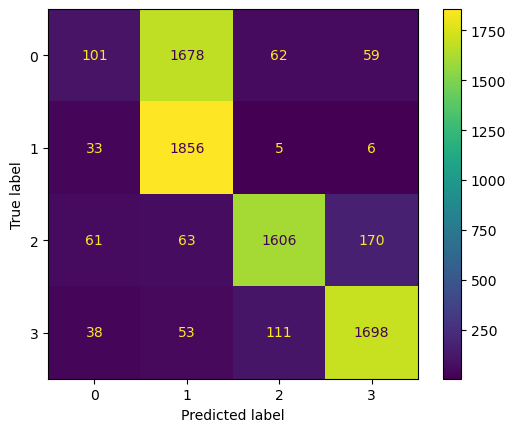

In [95]:
batch_conf_matrix(tokens_test, test_y, embedding, model_lstm, predictions)

  0%|          | 0/938 [00:00<?, ?it/s]

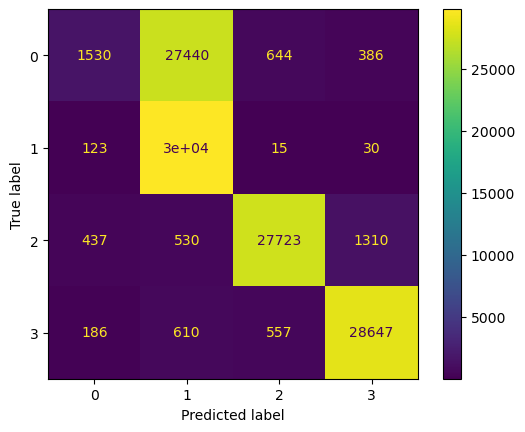

In [96]:
batch_conf_matrix(tokens_train, train_y, embedding, model_lstm, predictions)

In [132]:
def apply_rnn_fun(x: tf.Tensor, model: keras.Model, gen_state):
    batch_size = tf.shape(x)[0]
    state = gen_state(batch_size, x.dtype)
    n = tf.shape(x)[1]
    return tf.while_loop(
        (lambda i, _: tf.less(i, n)), 
        (lambda i, state: (i + 1, model(x[:, i], state)[1])),
        (tf.constant(0), state),
        maximum_iterations=121,
    )[1]

In [157]:
class LSTM(keras.layers.Layer):
    def __init__(self, ndim: int, name=None, **kwargs):
        super().__init__(name=name, **kwargs)

        self.forget_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'forget_gate'))
        self.input_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'input_gate'))
        self.tanh = keras.layers.Dense(ndim, activation='tanh', name=get_name(name, 'tanh'))
        self.output_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'output_gate'))
        self.get_state = get_gen_state_lstm(ndim)

    def __apply(self, x, state):
        xs = tf.concat([x, state[1]], -1)
        l = tf.multiply(state[0], self.forget_gate(xs))
        l = tf.add(l, tf.multiply(self.input_gate(xs), self.tanh(xs)))
        s = tf.multiply(self.output_gate(xs), keras.activations.tanh(l))
        state = (l, s)
        return state
    
    def call(self, x):
        shape = tf.shape(x)
        state = self.get_state(shape[0], x.dtype)

        return tf.while_loop(
            (lambda i, _: tf.less(i, shape[1])), 
            (lambda i, state: (i + 1, self.__apply(x[:, i], state))),
            (tf.constant(0), state),
            maximum_iterations=shape[1],
        )[1][1]
        # for i in range(shape[1]):
        #     xs = tf.concat([x[:, i], state[1]], -1)
            
        #     l = tf.multiply(state[0], self.forget_gate(xs))
        #     l = tf.add(l, tf.multiply(self.input_gate(xs), self.tanh(xs)))
        #     s = tf.multiply(self.output_gate(xs), keras.activations.tanh(l))
        #     state = (l, s)
        # return state[1]
    

In [158]:
inputs = keras.layers.Input((max_size,), dtype="int32", name="input")
l = get_lstm_layer(128, 'first')
x = keras.layers.Embedding(len(tokenizer.get_vocab()), 128, name="embedding")(inputs)
get_state = get_gen_state_lstm(128)
# x = keras.layers.Lambda(lambda x: apply_rnn_fun(x, l, get_state)[1], name="lstm_lambda", output_shape=(128,))(x)
x = LSTM(128, name="lstm")(x)
x = keras.layers.Dense(4, name="something")(x)
model = keras.Model(
    inputs=inputs,
    outputs=x,
    name="name"
)

In [159]:
model(tokens_train[:10])

<tf.Tensor: shape=(10, 4), dtype=float32, numpy=
array([[-0.0035319 ,  0.0134244 ,  0.0253093 , -0.01924318],
       [-0.0035319 ,  0.0134244 ,  0.0253093 , -0.01924319],
       [-0.0035319 ,  0.0134244 ,  0.02530929, -0.01924319],
       [-0.0035319 ,  0.0134244 ,  0.02530929, -0.01924319],
       [-0.0035319 ,  0.0134244 ,  0.02530929, -0.01924318],
       [-0.0035319 ,  0.0134244 ,  0.02530929, -0.01924319],
       [-0.0035319 ,  0.0134244 ,  0.0253093 , -0.01924319],
       [-0.0035319 ,  0.0134244 ,  0.02530929, -0.01924319],
       [-0.00352997,  0.01341952,  0.02531041, -0.01924139],
       [-0.0035319 ,  0.0134244 ,  0.02530929, -0.01924319]],
      dtype=float32)>

In [160]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [ ]:
model.fit(tokens_train, train_y, batch_size=batch_size, epochs=200)

In [164]:
model.evaluate(tokens_test, test_y)

2025-09-29 17:55:43.468950: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8', 4 bytes spill stores, 4 bytes spill loads



238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9192 - loss: 0.2743


[0.2742888629436493, 0.9192105531692505]

In [165]:
y_pred = model.predict(tokens_test)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


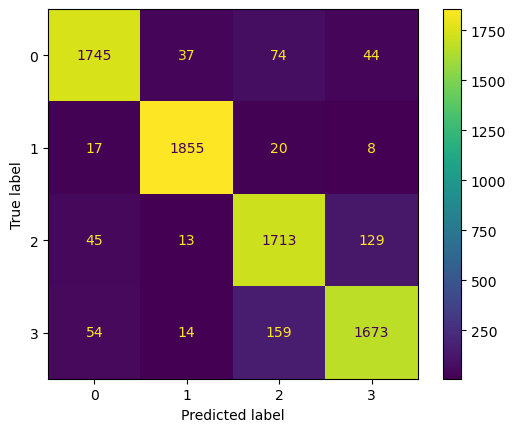

In [167]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(test_y, y_pred.argmax(axis=-1))

# GRU

In [169]:
def get_gen_state_gru(ndim: int):
    def gen_state_gru(batch_size: int, dtype: tf.DType):
        return tf.zeros([batch_size, ndim], dtype=dtype)

    return gen_state_gru

In [170]:
class GRU(keras.layers.Layer):
    def __init__(self, ndim: int, name=None, **kwargs):
        super().__init__(name=name, **kwargs)

        self.reset_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'reset_gate'))
        self.update_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'update_gate'))
        self.tanh = keras.layers.Dense(ndim, activation='tanh', name=get_name(name, 'tanh'))
        self.get_state = get_gen_state_gru(ndim)

    def __apply(self, x, state):
        xs = tf.concat([x, state], -1)
        
        xs_reset = tf.multiply(state, self.reset_gate(xs))
        xs_reset = tf.concat([xs_reset, x], -1)
        xs_reset = self.tanh(xs_reset)

        state_new = tf.multiply(state, self.update_gate(xs))
        state_new = state_new + (1 - self.update_gate(xs)) * xs_reset
        
        return state_new
    
    def call(self, x):
        shape = tf.shape(x)
        state = self.get_state(shape[0], x.dtype)

        return tf.while_loop(
            (lambda i, _: tf.less(i, shape[1])), 
            (lambda i, state: (i + 1, self.__apply(x[:, i], state))),
            (tf.constant(0), state),
            maximum_iterations=shape[1],
        )[1]
        # for i in range(shape[1]):
        #     xs = tf.concat([x[:, i], state[1]], -1)
            
        #     l = tf.multiply(state[0], self.forget_gate(xs))
        #     l = tf.add(l, tf.multiply(self.input_gate(xs), self.tanh(xs)))
        #     s = tf.multiply(self.output_gate(xs), keras.activations.tanh(l))
        #     state = (l, s)
        # return state[1]
    

In [171]:
inputs = keras.layers.Input((max_size,), dtype="int32", name="input")
x = keras.layers.Embedding(len(tokenizer.get_vocab()), 128, name="embedding")(inputs)
x = GRU(128, name="gru")(x)
x = keras.layers.Dense(4, name="something")(x)
model = keras.Model(
    inputs=inputs,
    outputs=x,
    name="name"
)

In [172]:
model(tokens_train[:10])

<tf.Tensor: shape=(10, 4), dtype=float32, numpy=
array([[ 0.06196589,  0.01804542, -0.03528886,  0.05489106],
       [ 0.06196589,  0.01804542, -0.03528886,  0.05489106],
       [ 0.06196589,  0.01804542, -0.03528886,  0.05489106],
       [ 0.06196589,  0.01804542, -0.03528886,  0.05489106],
       [ 0.06196589,  0.01804542, -0.03528886,  0.05489106],
       [ 0.06196589,  0.01804542, -0.03528886,  0.05489106],
       [ 0.06196589,  0.01804542, -0.03528886,  0.05489106],
       [ 0.06196589,  0.01804542, -0.03528886,  0.05489106],
       [ 0.06197675,  0.01804634, -0.0352838 ,  0.05489004],
       [ 0.06196589,  0.01804542, -0.03528886,  0.05489106]],
      dtype=float32)>

In [173]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [174]:
model.fit(tokens_train, train_y, batch_size=batch_size, epochs=200)

Epoch 1/200


2025-09-29 18:30:12.779570: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_61', 96 bytes spill stores, 100 bytes spill loads

2025-09-29 18:30:12.909374: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_61', 124 bytes spill stores, 124 bytes spill loads

2025-09-29 18:30:13.024175: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58', 704 bytes spill stores, 580 bytes spill loads

2025-09-29 18:30:13.164763: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58', 576 bytes spill stores, 480 bytes spill loads



934/938 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3380 - loss: 1.2607

2025-09-29 18:30:27.112264: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58', 576 bytes spill stores, 480 bytes spill loads

2025-09-29 18:30:27.130058: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58', 12 bytes spill stores, 12 bytes spill loads

2025-09-29 18:30:27.189279: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58', 120 bytes spill stores, 120 bytes spill loads

2025-09-29 18:30:27.240312: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58', 704 bytes spill stores, 580 bytes spill loads



938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.5481 - loss: 0.9163
Epoch 2/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9324 - loss: 0.2064
Epoch 3/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9603 - loss: 0.1233
Epoch 4/200
 85/938 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9798 - loss: 0.0616

KeyboardInterrupt: 

In [175]:
model.evaluate(tokens_test, test_y)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9184 - loss: 0.2932


[0.293181836605072, 0.9184210300445557]

In [176]:
y_pred = model.predict(tokens_test)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


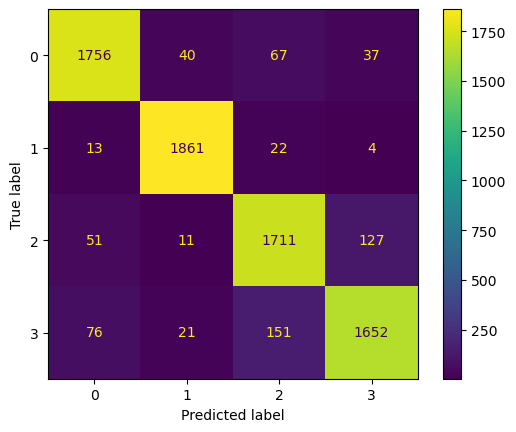

In [177]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(test_y, y_pred.argmax(axis=-1))

In [186]:
def get_gru_layer(ndim: int, name: None | str = None) -> Callable[[keras.KerasTensor, tuple[keras.KerasTensor, keras.KerasTensor]], tuple[keras.KerasTensor, tuple[keras.KerasTensor, keras.KerasTensor]]]:
    
    reset_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'reset_gate'))
    update_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'update_gate'))
    tanh = keras.layers.Dense(ndim, activation='tanh', name=get_name(name, 'tanh'))
    
    mul_1 = keras.layers.Multiply(name=get_name(name, 'mul_1'))
    mul_2 = keras.layers.Multiply(name=get_name(name, 'mul_2'))
    mul_3 = keras.layers.Multiply(name=get_name(name, 'mul_3'))
    add = keras.layers.Add(name=get_name(name, 'add'))
    concat = keras.layers.Concatenate(name=get_name(name, 'concat'))
    concat2 = keras.layers.Concatenate(name=get_name(name, 'concat2'))
    sub = keras.layers.Subtract(name=get_name(name, 'subtract'))
    lamb = keras.layers.Lambda(lambda x: tf.broadcast_to(tf.constant(1, dtype=x.dtype), tf.shape(x)) - x, name="helpl")
    
    def gru(x: keras.KerasTensor, state: keras.KerasTensor) -> tuple[keras.KerasTensor, keras.KerasTensor]:
        xs = concat([x, state])
        
        xs_reset = mul_1([state, reset_gate(xs)])
        xs_reset = concat2([xs_reset, x])
        xs_reset = tanh(xs_reset)
        aaaaa = update_gate(xs)
        
        state_new = mul_2([state, aaaaa])
        state_new = add([
            state_new,
            mul_3([
                lamb(aaaaa),
                xs_reset
            ])
        ])
        
        return state_new, state_new
    return gru

In [192]:
@tf.function
def apply_rnn(x: tf.Tensor, model: keras.Model, gen_state):
    batch_size = tf.shape(x)[0]
    state = gen_state(batch_size, x.dtype)
    n = tf.shape(x)[1]
    i = tf.constant(0)
    while i < n:
        _, state = model([x[:, i], state])
        i = i + 1
    return state

In [193]:
gru = get_gru_layer(128, 'second')

x_input = keras.layers.Input((128,), name='x')
h_input = keras.layers.Input((128,), name='h')

x = gru(x_input, h_input)

model_gru = keras.Model(inputs=[x_input, h_input], outputs=x)

In [195]:
embedding = keras.layers.Embedding(len(tokenizer.get_vocab()), 128, name="embedding")
predictions = keras.layers.Dense(4, name="dense_pred")
get_state = get_gen_state_gru(128)

epochs = 5
batch_size = 128

optimizer = keras.optimizers.Adam()

for epoch in tqdm.trange(epochs):
    for i in (pbar := tqdm.trange(0, len(tokens_train), batch_size, leave=False)):
        batch = tokens_train[i: i + batch_size]
        batch_y = train_y[i: i + batch_size]
        with tf.GradientTape() as tape:
            x = embedding(batch)
            x = apply_rnn(x, model_gru, get_state)
            x = predictions(x)
            loss = tf.nn.sparse_softmax_cross_entropy_with_logits(batch_y, x)
            loss = tf.reduce_mean(loss)
        gradients = tape.gradient(loss, (*embedding.weights, *model_gru.weights, *predictions.weights))
        optimizer.apply_gradients(zip(gradients, (*embedding.weights, *model_gru.weights, *predictions.weights)))
        pbar.set_description(f"Loss: {loss.numpy()}")

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]


KeyboardInterrupt

